In [ ]:
import os, pickle
import numpy as np
import pandas as pd

from models import carl, taylr
from physics.simulation import mcfm, msq
from physics.hzz import zz4l
from physics.hstar import c6

import torch
from torch.utils.data import TensorDataset, DataLoader
import lightning as L

In [77]:
torch.set_float32_matmul_precision('high')

import matplotlib, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "lualatex",
    "text.usetex": True,
    "pgf.rcfonts": False,
    "pgf.preamble": "", 
})

In [2]:
RUN_DIR = 'run/h4l/'
DATA_DIR = 'data/'

CARL_CKPT = [36,0.68]
TAYLR_CKPTS = [[30,0.08],[21,0.15],[25,0.08],[194,0.05]]
NCOEFFS = len(TAYLR_CKPTS)

CARL_DIR = 'carl/'
TAYLR_DIRS = [f'taylr_{i+1}/' for i in range(NCOEFFS)]

LOGS_DIR = 'lightning_logs/version_0'

SAMPLE_FILE_GG = 'ggZZ2e2m_sbi/events.csv'
SAMPLE_FILE_QQ = 'qqZZ2e2m/events.csv'

CARL_CKPT_PATH = os.path.join(RUN_DIR, CARL_DIR, LOGS_DIR, 'checkpoints', f'epoch={CARL_CKPT[0]}-val_loss={CARL_CKPT[1]}.ckpt')
TAYLR_CKPT_PATHs = [os.path.join(RUN_DIR, TAYLR_DIRS[i], LOGS_DIR, 'checkpoints', f'epoch={TAYLR_CKPTS[i][0]}-val_loss={TAYLR_CKPTS[i][1]}.ckpt') for i in range(NCOEFFS)]

SAMPLE_PATH_GG = os.path.join(DATA_DIR, SAMPLE_FILE_GG)
SAMPLE_PATH_QQ = os.path.join(DATA_DIR, SAMPLE_FILE_QQ)

In [3]:
sample_size = 100000

features = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

batch_size = 512

lumi_hllhc = 3000

c6_linspace = [-20,20,201]
cH_linspace = [-0.02,0.05,71]

c6_space = np.linspace(*c6_linspace)
cH_space = np.linspace(*cH_linspace)

c6_val_asimov = 0.0
cH_val_asimov = 0.0

In [4]:
xs = {'ggZZ': 1.5569109*4, 'qqZZ': 14.482054*4}

In [5]:
events_gg = mcfm.from_csv(cross_section=xs['ggZZ'], file_path=SAMPLE_PATH_GG)
events_qq = mcfm.from_csv(cross_section=xs['qqZZ'], file_path=SAMPLE_PATH_QQ)
# events_pp = mcfm.from_csv()

events_gg = events_gg.sample(sample_size)
events_qq = events_qq.sample(sample_size)

events_gg = zz4l.analyze(events_gg)
events_qq = zz4l.analyze(events_qq)

w_gg_sm = events_gg.weights.to_numpy()
w_qq_sm = events_qq.weights.to_numpy()

sigma_gg_sm = events_gg.weights.sum()
sigma_qq_sm = events_qq.weights.sum()

In [6]:
c6_mod = c6.Modifier(baseline=msq.Component.SBI, events=events_gg, c6_values=[-10, -5, 0, 5, 10])
w_gg_c6, p_gg_c6 = c6_mod.modify(c6=c6_space)

In [7]:
c6_asimov_index = np.where(c6_space==c6_val_asimov)[0][0]
c6_zero_index = np.where(c6_space==0.0)[0][0]

cH_asimov_index = np.where(np.round(cH_space,4)==cH_val_asimov)[0][0]
cH_zero_index = np.where(np.round(cH_space,4)==0.0)[0][0]

## Generate $pp = gg+qq$ events

In [8]:
p_true = np.array([np.concatenate([w_gg_c6[:,i], events_qq.weights]) for i in range(w_gg_c6.shape[1])])
p_true /= np.sum(p_true, axis=1)[:, np.newaxis]

In [9]:
w_gg_cH_asimov = w_gg_c6[:,c6_asimov_index] - 2*cH_val_asimov*w_gg_c6[:,c6_zero_index]
events_pp = mcfm.Process(pd.concat([events_gg.kinematics, events_qq.kinematics],ignore_index=True).reset_index(drop=True),
                pd.concat([events_gg.components, events_qq.components],ignore_index=True).reset_index(drop=True),
                pd.concat([pd.Series(w_gg_cH_asimov), pd.Series(w_qq_sm)],ignore_index=True).reset_index(drop=True))
sigma_pp_asimov = events_pp.weights.sum()

In [11]:
kinematics_gg = events_gg.kinematics[features]
kinematics_pp = events_pp.kinematics[features]

In [12]:
model_carl = carl.CARL.load_from_checkpoint(checkpoint_path=CARL_CKPT_PATH)
models_taylr = [taylr.TAYLR.load_from_checkpoint(checkpoint_path=path) for path in TAYLR_CKPT_PATHs]

In [13]:
with open(os.path.join(RUN_DIR, CARL_DIR, 'scaler.pkl'), 'rb') as f:
    scaler_carl = pickle.load(f)
X_carl = scaler_carl.transform(kinematics_gg.to_numpy())
dl_carl = DataLoader(TensorDataset(torch.tensor(X_carl, dtype=torch.float32)), batch_size=BATCH_SIZE, num_workers=8)

trainer = L.Trainer(accelerator='gpu', devices=1)
s_carl = torch.concatenate(trainer.predict(model_carl, dl_carl)).numpy()

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/afs/ipp-garching.mpg.de/home/t/taepa/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: ModelCheckpoint
You are using a CUDA devic

Predicting: |                                                                                                 …

In [14]:
r = s_carl/(1-s_carl)

## CARL calibration

In [15]:
# carl_calib = 1/np.sum(r * w_gg_sm / np.sum(w_gg_sm))
# r_calib = r * carl_calib

In [16]:
dls_taylr = []
for i in range(NCOEFFS):
    with open(os.path.join(RUN_DIR, TAYLR_DIRS[i], 'scaler_X.pkl'), 'rb') as f:
        scaler_X = pickle.load(f)
    X_taylr = scaler_X.transform(kinematics_gg.to_numpy())
    X_taylr = torch.tensor(X_taylr, dtype=torch.float32) 
    y_taylr = torch.tensor(np.ones(kinematics_gg.shape[0]))
    w_taylr = torch.tensor(np.ones(kinematics_gg.shape[0]))
    dl = DataLoader(TensorDataset(X_taylr, y_taylr, w_taylr), batch_size=BATCH_SIZE, num_workers=8)
    dls_taylr.append(dl)

In [17]:
coeffs_pred = []
for i in range(NCOEFFS):
    with open(os.path.join(RUN_DIR, TAYLR_DIRS[i], 'scaler_y.pkl'), 'rb') as f:
        scaler_y = pickle.load(f)
    coeffs_pred.append(scaler_y.inverse_transform(torch.concatenate(trainer.predict(models_taylr[i], dls_taylr[i])).numpy()[:,np.newaxis]).flatten())
coeffs_pred = np.array(coeffs_pred).T

coeffs_true = c6_mod.coefficients[:,1:]

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting: |                                                                                                 …

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting: |                                                                                                 …

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting: |                                                                                                 …

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Predicting: |                                                                                                 …

In [18]:
def f(c6_values, coeffs):
    coefficients = np.concatenate([np.ones((len(coeffs),1)), coeffs], axis=1)
    c6_matrix = np.vander(c6_values, coefficients.shape[1], increasing=True).T
    return np.dot(coefficients, c6_matrix)

In [19]:
c6_values = c6_space
cH_values = cH_space

# truth estimate
# w_gg_c6_cH = w_gg_c6[:,:,np.newaxis] - 2 * (w_gg_sm[:,np.newaxis,np.newaxis] * cH_values[np.newaxis,np.newaxis,:])
w_gg_c6 = w_gg_sm[:,np.newaxis] * f(c6_values, coeffs_true)
w_gg_c6_cH = w_gg_c6[:,:,np.newaxis] - 2 * (w_gg_sm[:,np.newaxis,np.newaxis] * cH_values[np.newaxis,np.newaxis,:])
sigma_gg_c6_cH = np.sum(w_gg_c6_cH, axis=0)

# NSBI estimate
w_gg_c6_nsbi = w_gg_sm[:,np.newaxis] * f(c6_values, coeffs_pred)
w_gg_c6_cH_nsbi = w_gg_c6_nsbi[:,:,np.newaxis] - 2 * (w_gg_sm[:,np.newaxis,np.newaxis] * cH_values[np.newaxis,np.newaxis,:])
sigma_gg_c6_cH_nsbi = np.sum(w_gg_c6_cH_nsbi, axis=0)  # c6 & cH

In [21]:
nu_gg_sm = sigma_gg_sm * lumi_hllhc
nu_gg_bsm = sigma_gg_c6_cH * lumi_hllhc
nu_gg_bsm_nsbi = sigma_gg_c6_cH_nsbi * lumi_hllhc

sigma_pp_sm = sigma_gg_sm + sigma_qq_sm
sigma_pp_bsm_nsbi = sigma_gg_c6_cH_nsbi + sigma_qq_sm

nu_pp_sm = sigma_pp_sm * lumi_hllhc
nu_pp_bsm_nsbi = sigma_pp_bsm_nsbi * lumi_hllhc

In [22]:
n_gg_asimov = sigma_gg_sm*lumi_hllhc
n_pp_asimov = sigma_pp_asimov*lumi_hllhc

# Poisson term
t_rate = -2 * nu_gg_sm * (np.log(nu_gg_bsm) - np.log(nu_gg_sm)) + 2 * (nu_gg_bsm - nu_gg_sm) 
t_rate_nsbi = -2 * nu_gg_sm * (np.log(nu_gg_bsm_nsbi) - np.log(nu_gg_sm)) + 2 * (nu_gg_bsm_nsbi - nu_gg_sm) 

In [23]:
p_ratio =  (w_gg_c6_cH / sigma_gg_c6_cH) / (w_gg_sm[:,np.newaxis,np.newaxis] / sigma_gg_sm)
p_ratio_nsbi = (w_gg_c6_cH_nsbi / sigma_gg_c6_cH_nsbi) / (w_gg_sm[:,np.newaxis,np.newaxis] / sigma_gg_sm)

In [24]:
p_true = np.array([np.concatenate([w_gg_c6[:,i], events_qq.weights]) for i in range(w_gg_c6.shape[1])])
p_true /= np.sum(p_true, axis=1)[:, np.newaxis]

In [25]:
# print(np.sum(w_gg_c6_cH / sigma_gg_c6_cH, axis=0))
# print(np.sum(w_gg_c6_cH_nsbi / sigma_gg_c6_cH_nsbi, axis=0))
print(np.sum(w_gg_sm[:,np.newaxis,np.newaxis] / sigma_gg_sm,axis=1))

[[2.41643210e-05]
 [1.10539794e-05]
 [4.30747196e-06]
 ...
 [4.18359207e-06]
 [1.40380532e-05]
 [1.03090209e-05]]


In [26]:
#rescaling_factor = np.sum(p_ratio * true_probs[c6_zero_index,:][np.newaxis,:,np.newaxis], axis=1)
#p_ratio_fixed = p_ratio/rescaling_factor[:,np.newaxis]

In [27]:
# # Used for ggZZ + qqZZ

# batch_size = 10000

# t_3 = np.zeros((C6_LINSPACE[2],CH_LINSPACE[2]))

# rescaling_factor = np.zeros((C6_LINSPACE[2],CH_LINSPACE[2]))

# for start_idx in range(0,sample_size,batch_size):
#     end_idx = min(start_idx + batch_size, sample_size)
#     if start_idx % 100*batch_size == 0:
#         print(start_idx, end_idx)

#     batch_weights = events_final.weights.to_numpy()[np.newaxis,start_idx:end_idx,np.newaxis]
#     batch_pratio = full_SM_xs/full_BSM_xs[:,np.newaxis] * (f(c6_values, coeffs_pred[start_idx:end_idx])[:,:,np.newaxis] - 2*cH_space[np.newaxis,np.newaxis,:] + sigma_qqZZ/sigma_ggZZ*r[np.newaxis,start_idx:end_idx,np.newaxis])/(1 + sigma_qqZZ/sigma_ggZZ * r[np.newaxis,start_idx:end_idx,np.newaxis])
#     batch_log_term = np.log(batch_pratio)

#     rescaling_factor += np.sum(batch_pratio * true_probs[c6_zero_index,:][np.newaxis,start_idx:end_idx,np.newaxis], axis=1)

#     t_3 += -2*luminosity*np.sum(batch_weights*batch_log_term, axis=1)

# t_3 += 2*luminosity*sigma_data*np.log(rescaling_factor)

# #t_3 = -2 * np.sum(luminosity*events_final.weights.to_numpy()[np.newaxis,:,np.newaxis] * np.log(p_ratio_fixed), axis=1)

In [28]:
t_shape = - 2 * np.sum(lumi_hllhc * w_gg_sm[:,np.newaxis,np.newaxis] * np.log(p_ratio) , axis=0)
t_shape_nsbi = - 2 * np.sum(lumi_hllhc * w_gg_sm[:,np.newaxis,np.newaxis] * np.log(p_ratio_nsbi) , axis=0)

/tmp/ipykernel_845653/1278165770.py:1: RuntimeWarning: invalid value encountered in log
  t_shape = - 2 * np.sum(LUMI * w_gg_sm[:,np.newaxis,np.newaxis] * np.log(p_ratio) , axis=0)


In [53]:
t = t_rate + t_shape 
t_nsbi = t_rate_nsbi + t_shape_nsbi

In [60]:
i_c6_fit = np.nanargmin(t) // CH_LINSPACE[2]
i_cH_fit = np.nanargmin(t)  % CH_LINSPACE[2]

i_c6_fit_nsbi = np.nanargmin(t_nsbi) // CH_LINSPACE[2]
i_cH_fit_nsbi = np.nanargmin(t_nsbi)  % CH_LINSPACE[2]

i_c6_fit_rate = np.nanargmin(t_rate) // CH_LINSPACE[2]
i_cH_fit_rate = np.nanargmin(t_rate)  % CH_LINSPACE[2]

t_min = t[i_c6_fit,i_cH_fit]
t_min_nsbi = t_nsbi[i_c6_fit_nsbi,i_cH_fit_nsbi]
t_min_rate = t_rate[i_c6_fit_rate,i_cH_fit_rate]

In [65]:
X, Y = np.meshgrid(c6_values, cH_values)
Z = t.T
Z_nsbi = t_nsbi.T
Z_rate = t_rate.T

In [80]:
plt.figure(figsize=(6,4))

contours = plt.contour(X, Y, Z, levels=[t_min+1,t_min+4], colors='royalblue', linestyles=['--','-'])
contours_nsbi = plt.contour(X, Y, Z_nsbi, levels=[t_min_nsbi+1,t_min_nsbi+4], colors='black', linestyles=['--','-'])
contours_rate = plt.contour(X, Y, Z_rate, levels=[t_min_rate+1,t_min_rate+4], colors='grey', linestyles=['--','-'])

# plt.clabel(contours, fmt=dict(zip([t_min+1,t_min+4], ['$1\sigma$', '$2\sigma$'])))

plt.scatter(c6_values[i_c6_fit], cH_values[i_cH_fit], marker='+', color='blue')
plt.scatter(c6_values[i_c6_fit_nsbi], cH_values[i_cH_fit_nsbi], marker='x', color='black')

labels = [
    Line2D([0],[0],color='royalblue',label='$\\mathrm{Truth}$'),
    Line2D([0],[0],color='grey',label='$\\mathrm{Rate}$'),
    Line2D([0],[0],color='black',label='$\\mathrm{NSBI}$'),
]
plt.legend(frameon=False, handles=labels, loc='upper center')

plt.xlabel('$c_6$', fontsize=12)
plt.ylabel('$c_H$', fontsize=12)

plt.xlim(-20,20)
plt.ylim(-0.01,0.02)

plt.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig('nll_gg.pdf', bbox_inches='tight')

In [75]:
t_min = c6_values[np.nanargmin(t, axis=0)][cH_zero_index]

In [37]:
ci = np.sort(np.round(c6_values[np.argsort(np.abs(t-(np.min(t)+1)))[:2]], 2))
ci_2 = np.sort(np.round(c6_values[np.argsort(np.abs(t-(np.min(t)+4)))[:2]], 2))

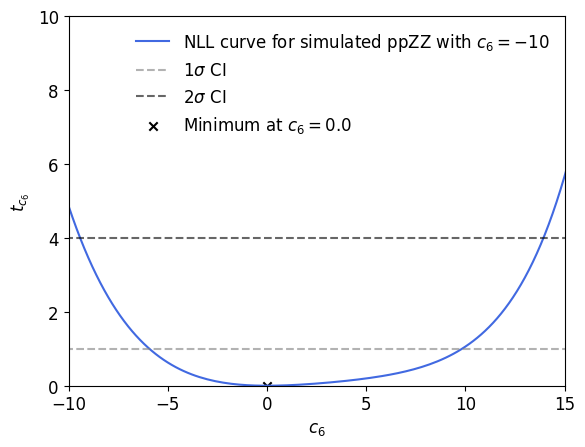

In [38]:
plt.plot(c6_values, t[:,cH_zero_index], color='royalblue', label=f'NLL curve for simulated ppZZ with $c_6 = {c6_val_asimov}$')
plt.hlines(np.min(t[:,cH_zero_index])+1, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], linestyle='--', color='grey', alpha=0.6, label=f'$1\sigma$ CI')# [{ci[0]},{ci[1]}]')
plt.hlines(np.min(t[:,cH_zero_index])+4, xmin=C6_LINSPACE[0], xmax=C6_LINSPACE[1], linestyle='--', color='k', alpha=0.6, label=f'$2\sigma$ CI')# [{ci_2[0]},{ci_2[1]}]')
plt.scatter(t_min, np.min(t[:,cH_zero_index]), color='k', marker='x', label=f'Minimum at $c_6 = {round(t_min,2)}$')

#plt.scatter([-15.4, 19.1],[np.min(t[:,cH_zero_index])+4, np.min(t[:,cH_zero_index])+4],marker='x') #c6=-10
#plt.scatter([-13.2, 17.9],[np.min(t[:,25])+4, np.min(t[:,25])+4],marker='x') #c6=10

plt.xlabel('$c_6$', fontsize=12)
plt.ylabel('$t_{c_6}$', fontsize=12)
plt.ylim(-0,10)
plt.xlim(-10,15)
#plt.yscale('log')

plt.tick_params(axis='both', labelsize=12)

plt.legend(frameon=False, fontsize=12)
plt.show()